# Le sous et le sur entraînement

Les deux principaux défis que vous rencontrerez lors de votre parcours en data science sont le sous-entraînement et le sur-entraînement.

Votre modèle sera sous-entraîné s'il n'est pas assez complexe pour résoudre votre problème.

À l'inverse, un modèle sur-entraîné sera trop complexe pour votre problème. Il apprendra à mémoriser les données d'entraînement plutôt qu'à comprendre comment résoudre le problème de manière générale.

Dans ce notebook, nous explorerons des exemples de sous-entraînement et de sur-entraînement, et nous verrons comment surmonter ces problèmes.

## Problème à résoudre

Dans ce notebook on va tenter de créer un modèle capable de résoudre éfficacement le problème du jeu de données [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist). Le but est de prédire à quelle classe de vêtement chaque photo appartient. Nous avons 60 000 photos pour notre entraînement et 10 000 pour notre test. Ces images sont des photos de dimension 28x28 en intensité de gris.

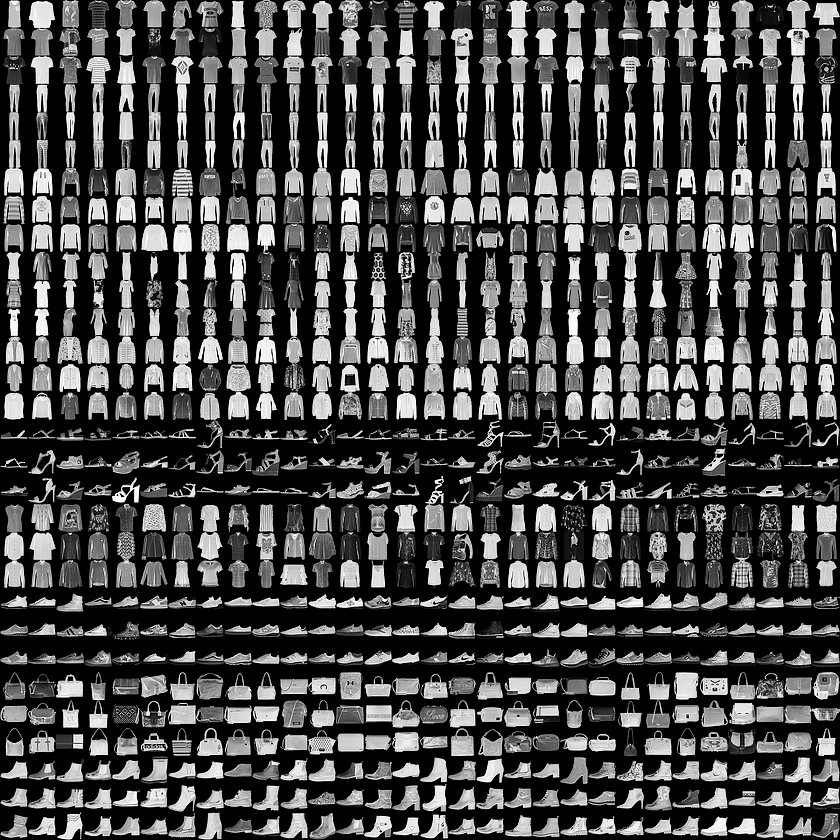

Ces photos appartiennent à 10 classes :
- les T-shirts ;
- les pantalons ;
- les pullover ;
- les robes ;
- les manteaux ;
- les sandales ;
- les chemises ;
- les baskettes ;
- les sacs ;
- les bottes.

## Importations des bibliothèques

Importons les bibliothèques dont nous allons avoir besoin dans ce notebook.

In [1]:
import torch

from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import numpy as np

from torch.utils.data import Subset

## Importations des données

Nous pouvons importer les images directement via PyTorch.

In [2]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(0.5, 0.5)])
# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=2048, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=2048, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]


# Visualisation d'une image

In [3]:
x, y = next(iter(trainset))

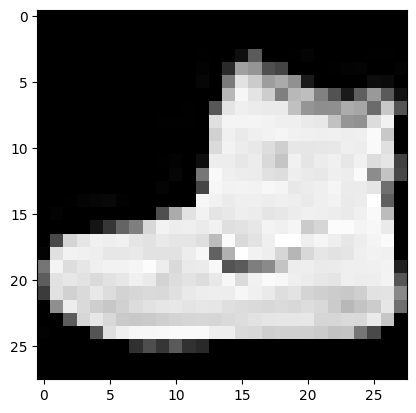

In [4]:
# Show one of the images from the training dataset
plt.imshow(x[0, : ,:], cmap='Greys_r')
plt.show()

# Les fonctions d'entraînement

Métriques de performance

In [5]:
def number_of_good_prediction(prediction:float, target:int):
  one_hot_prediction = np.argmax(prediction, axis=1)
  return np.sum(one_hot_prediction == target)

In [6]:
def step(model:torch.nn.Sequential,
         opt:torch.optim,
         criterion:torch.nn.modules.loss,
         x_train:torch.Tensor,
         y_train:torch.Tensor,
         metric_function)->tuple:
  """
  Executes a single training step for a PyTorch model.
  This function performs a forward pass to compute the model's predictions, calculates
  the loss between predictions and actual target values, computes gradients for each
  model parameter, and updates the parameters using the optimizer.

  Args:
      model (torch.nn.Sequential): The PyTorch model to train.
      opt (torch.optim.Optimizer): Optimizer used to update the model's parameters.
      criterion (torch.nn.modules.loss._Loss): Loss function used to compute the error.
      x_train (torch.Tensor): Input training data (features).
      y_train (torch.Tensor): Ground truth labels or target values for the training data.
  Returns:
      tuple: The updated model and the computed loss for the current step.
  """

  # Réinitialisez les gradients d'optimizer à zéro avec la méthode 'zero_grad'
  opt.zero_grad()

  # Calculez les prédiction sur le jeu d'entraînement avec la méthode 'froward'
  prediction = model.forward(x_train)

  # Calculez l'erreur de prédiction avec 'criterion'
  loss = criterion(prediction, y_train)

  performance = metric_function(prediction.detach().numpy(), y_train.detach().numpy())

  # Calculez les gradients avec la méthode 'backward'
  loss.backward()

  # Mettre à jour les paramètres du modèle avec la méthode 'step'
  opt.step()

  return model, loss, performance

In [7]:
def fit(model, optimizer, criterion, epoch, trainloader, testloader, metric_function):
    epoch = epoch
    history_train_loss = []
    history_test_loss = []
    history_train_metrics = []
    history_test_metrics = []

    for e in range(epoch) :

      train_loss_batch = 0
      test_loss_batch = 0
      train_metric_batch = 0
      test_metric_batch = 0

      for images, labels in trainloader:

        images = images.view(images.shape[0], -1)

        # mise à jour des poids avec la fonction 'step'
        model, train_loss, train_performance = step(model, optimizer, criterion, images, labels, metric_function)

        train_loss_batch += train_loss.detach().numpy()

        train_metric_batch += train_performance


      for images, labels in testloader:

        images = images.view(images.shape[0], -1)

        prediction = model.forward(images)

        test_loss = criterion(prediction, labels)

        test_metric_batch += metric_function(prediction.detach().numpy(), labels.detach().numpy())

        test_loss_batch += test_loss.detach().numpy()

      train_loss_batch /= len(trainloader.sampler)
      test_loss_batch /= len(testloader.sampler)

      train_metric_batch /= len(trainloader.sampler)
      test_metric_batch /= len(testloader.sampler)

      # Sauvegarde des coûts d'entraînement avec append
      history_train_loss = np.append(history_train_loss, train_loss_batch)
      history_test_loss = np.append(history_test_loss, test_loss_batch)

      # Sauvegarde des coûts d'entraînement avec append
      history_train_metrics = np.append(history_train_metrics, train_metric_batch)
      history_test_metrics = np.append(history_test_metrics, test_metric_batch)

      print('train_loss : '+str(np.squeeze(train_loss_batch))+ ' test_loss : '+str(np.squeeze(test_loss_batch)))
      print('train_metric : '+str(np.squeeze(train_metric_batch))+ ' test_metric : '+str(np.squeeze(test_metric_batch)))
      print('-------------------------------------------------------------------------------------------------')

    return model, history_train_loss, history_test_loss, history_train_metrics, history_test_metrics


## Le sous entraînement

## Initialisation de l'architecture

Initialisez un modèle avec :
- Une couche de neurones avec 784 données en entrée et 10 neurones.
- Une couche d'activation LogSoftmax.

In [8]:
model = torch.nn.Sequential(torch.nn.Linear(784, 10),
                            torch.nn.LogSoftmax(dim=1))

In [9]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
epoch=5

In [11]:
model, history_train_loss, history_test_loss, history_train_metrics, history_test = fit(model, optimizer, criterion, epoch, trainloader, testloader, number_of_good_prediction)

train_loss : 0.00059292035 test_loss : 0.00038697346
train_metric : 0.61675 test_metric : 0.7339
-------------------------------------------------------------------------------------------------
train_loss : 0.00034350838 test_loss : 0.0003261867
train_metric : 0.7646333333333334 test_metric : 0.7723
-------------------------------------------------------------------------------------------------
train_loss : 0.00030214913 test_loss : 0.0002993994
train_metric : 0.7944166666666667 test_metric : 0.7929
-------------------------------------------------------------------------------------------------
train_loss : 0.00028016345 test_loss : 0.00028480758
train_metric : 0.80965 test_metric : 0.8018
-------------------------------------------------------------------------------------------------
train_loss : 0.00026718143 test_loss : 0.00027335962
train_metric : 0.8196833333333333 test_metric : 0.8103
--------------------------------------------------------------------------------------------

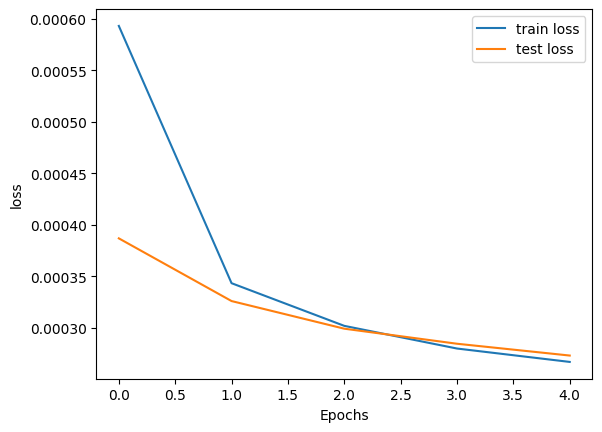

In [12]:
plt.plot(np.arange(epoch), history_train_loss, label='train loss')
plt.plot(np.arange(epoch), history_test_loss, label='test loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(loc='upper left')
plt.legend()
plt.show()

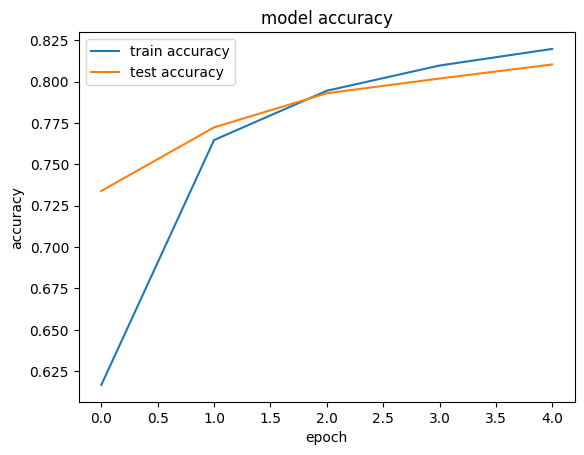

In [13]:
plt.plot(history_train_metrics, label='train accuracy')
plt.plot(history_test, label='test accuracy')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

La loss et la performance du jeu d'entraînement et de test sont très proche les unes des autres sans être très haute. C'est de cette façon que l'on repère le sous apprentissage.

Deux options s'offre à nous :
- Augmenter la complexité du modèle,
- Continuer l'apprentissage,
- Changer le type de modèle.

**Augmentez le nombre d'epochs de votre modèle à 10**

In [14]:
model = torch.nn.Sequential(torch.nn.Linear(784, 10),
                            torch.nn.LogSoftmax(dim=1))

In [15]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
epoch_2=10

In [17]:
model, history_train_loss_2, history_test_loss_2, history_train_metrics_2, history_test_2 = fit(model, optimizer, criterion, epoch_2, trainloader, testloader, number_of_good_prediction)

train_loss : 0.00057149807 test_loss : 0.00037677443
train_metric : 0.64405 test_metric : 0.7374
-------------------------------------------------------------------------------------------------
train_loss : 0.00033637354 test_loss : 0.00031975243
train_metric : 0.7697666666666667 test_metric : 0.7786
-------------------------------------------------------------------------------------------------
train_loss : 0.00029672842 test_loss : 0.00029378265
train_metric : 0.7986166666666666 test_metric : 0.7998
-------------------------------------------------------------------------------------------------
train_loss : 0.0002762308 test_loss : 0.00027978374
train_metric : 0.8125666666666667 test_metric : 0.8103
-------------------------------------------------------------------------------------------------
train_loss : 0.00026306038 test_loss : 0.00026995887
train_metric : 0.82065 test_metric : 0.8152
-------------------------------------------------------------------------------------------

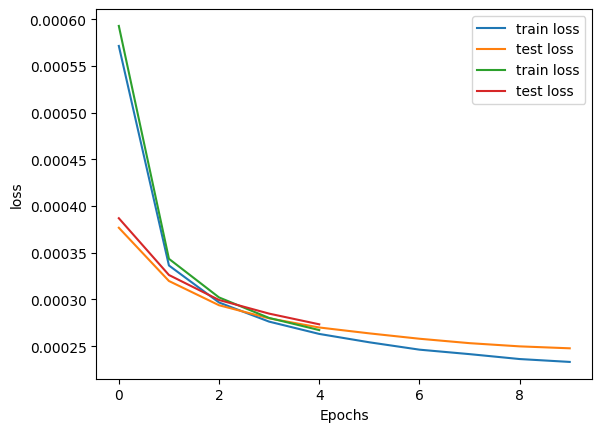

In [18]:
plt.plot(np.arange(epoch_2), history_train_loss_2, label='train loss')
plt.plot(np.arange(epoch_2), history_test_loss_2, label='test loss')
plt.plot(np.arange(epoch), history_train_loss, label='train loss')
plt.plot(np.arange(epoch), history_test_loss, label='test loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(loc='upper left')
plt.legend()
plt.show()

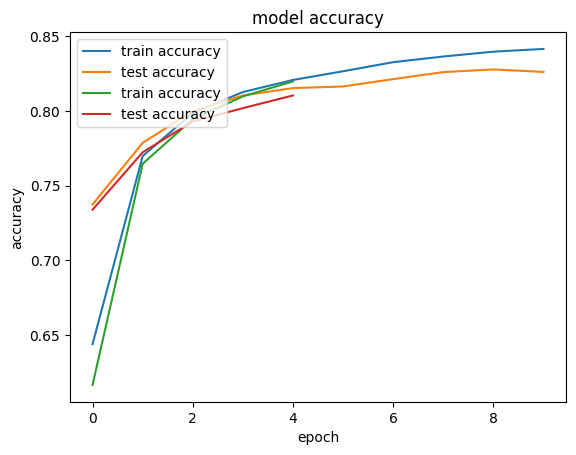

In [19]:
plt.plot(history_train_metrics_2, label='train accuracy')
plt.plot(history_test_2, label='test accuracy')
plt.plot(history_train_metrics, label='train accuracy')
plt.plot(history_test, label='test accuracy')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

**Augmentez la complexité du modèle**

Initialisez un modèle avec :
- Une couche cachée de 128 neurones (ReLU) ;
- Une couche cachée de 64 neurones (ReLU) ;
- Une couche de sortie avec 10 neurones et une fonction d'activation LogSoftmax.

In [20]:
model = torch.nn.Sequential(torch.nn.Linear(784, 128),
                            torch.nn.ReLU(),
                            torch.nn.Linear(128, 64),
                            torch.nn.ReLU(),
                            torch.nn.Linear(64, 10),
                            torch.nn.LogSoftmax(dim=1))

In [21]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
epoch_3=10

In [ ]:
model, history_train_loss_3, history_test_loss_3, history_train_metrics_3, history_test_3 = fit(model, optimizer, criterion, epoch_3, trainloader, testloader, number_of_good_prediction)

train_loss : 0.0005940955 test_loss : 0.00033859955
train_metric : 0.6194833333333334 test_metric : 0.7466
-------------------------------------------------------------------------------------------------
train_loss : 0.0002882357 test_loss : 0.0002723184
train_metric : 0.7910333333333334 test_metric : 0.8036
-------------------------------------------------------------------------------------------------
train_loss : 0.00024556436 test_loss : 0.00024638325
train_metric : 0.8269166666666666 test_metric : 0.8221
-------------------------------------------------------------------------------------------------
train_loss : 0.00022332782 test_loss : 0.00023101516
train_metric : 0.8419333333333333 test_metric : 0.835
-------------------------------------------------------------------------------------------------
train_loss : 0.00021065256 test_loss : 0.00022231875
train_metric : 0.8513 test_metric : 0.8421
------------------------------------------------------------------------------------

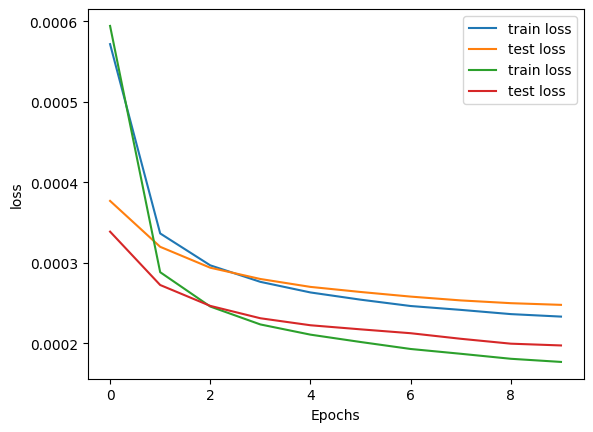

In [ ]:
plt.plot(np.arange(epoch_2), history_train_loss_2, label='train loss')
plt.plot(np.arange(epoch_2), history_test_loss_2, label='test loss')
plt.plot(np.arange(epoch_2), history_train_loss_3, label='train loss')
plt.plot(np.arange(epoch_2), history_test_loss_3, label='test loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(loc='upper left')
plt.legend()
plt.show()

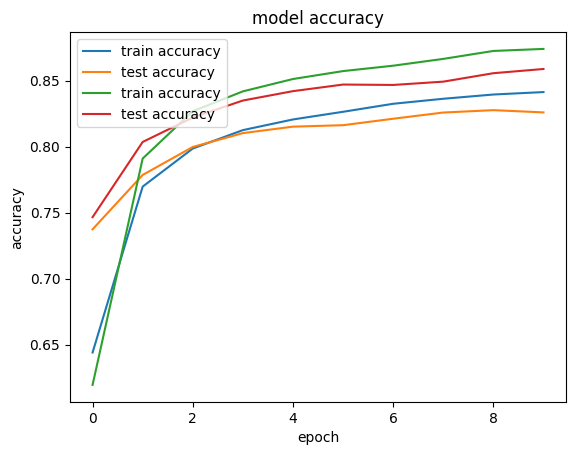

In [ ]:
plt.plot(history_train_metrics_2, label='train accuracy')
plt.plot(history_test_2, label='test accuracy')
plt.plot(history_train_metrics_3, label='train accuracy')
plt.plot(history_test_3, label='test accuracy')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

On peut voir que complexifier le modèle améliore les résultats du modèle.

Un autre moyen d'augmenter la performance de notre modèle serait d'utiliser une architecture spécifique aux traitements d'images comme le convolutional neural network.

# Le sur-entraînement

In [ ]:
model = torch.nn.Sequential(torch.nn.Linear(784, 256),
                            torch.nn.ReLU(),
                            torch.nn.Linear(256, 256),
                            torch.nn.ReLU(),
                            torch.nn.Linear(256, 256),
                            torch.nn.ReLU(),
                            torch.nn.Linear(256, 128),
                            torch.nn.ReLU(),
                            torch.nn.Linear(128, 128),
                            torch.nn.ReLU(),
                            torch.nn.Linear(128, 128),
                            torch.nn.ReLU(),
                            torch.nn.Linear(128, 64),
                            torch.nn.ReLU(),
                            torch.nn.Linear(64, 64),
                            torch.nn.ReLU(),
                            torch.nn.Linear(64, 64),
                            torch.nn.ReLU(),
                            torch.nn.Linear(64, 32),
                            torch.nn.ReLU(),
                            torch.nn.Linear(32, 32),
                            torch.nn.ReLU(),
                            torch.nn.Linear(32, 32),
                            torch.nn.ReLU(),
                            torch.nn.Linear(32, 10),
                            torch.nn.ReLU(),
                            torch.nn.Linear(10, 10),
                            torch.nn.ReLU(),
                            torch.nn.Linear(10, 10),
                            torch.nn.LogSoftmax(dim=1))

In [ ]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epoch=40

In [ ]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(0.5, 0.5)])
# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
trainloader_few = torch.utils.data.DataLoader(Subset(trainset, range(5000)), batch_size=2048, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=2048, shuffle=True)

In [ ]:
model, history_train_loss, history_test_loss, history_train_metrics, history_test_metrics = fit(model, optimizer, criterion, epoch, trainloader_few, testloader, number_of_good_prediction)

train_loss : 0.0013890296 test_loss : 0.0011564876
train_metric : 0.0986 test_metric : 0.1
-------------------------------------------------------------------------------------------------
train_loss : 0.0013887085 test_loss : 0.0011560569
train_metric : 0.0986 test_metric : 0.1
-------------------------------------------------------------------------------------------------
train_loss : 0.0013887488 test_loss : 0.0011554635
train_metric : 0.0986 test_metric : 0.1
-------------------------------------------------------------------------------------------------
train_loss : 0.0013866385 test_loss : 0.0011547549
train_metric : 0.0986 test_metric : 0.1
-------------------------------------------------------------------------------------------------
train_loss : 0.0013854929 test_loss : 0.0011536388
train_metric : 0.0986 test_metric : 0.1
-------------------------------------------------------------------------------------------------
train_loss : 0.0013843592 test_loss : 0.001150928
train

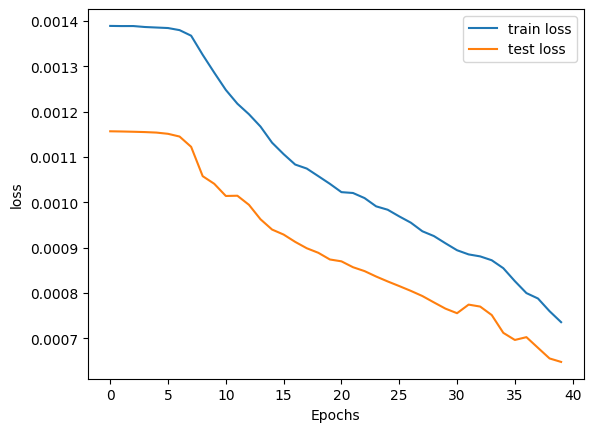

In [ ]:
plt.plot(np.arange(epoch), history_train_loss, label='train loss')
plt.plot(np.arange(epoch), history_test_loss, label='test loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(loc='upper left')
plt.legend()
plt.show()

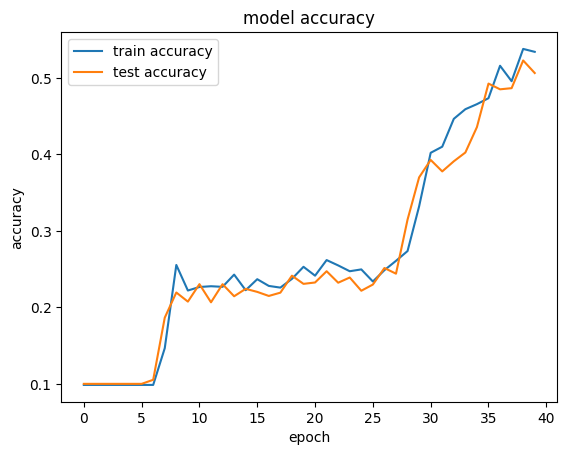

In [ ]:
plt.plot(history_train_metrics, label='train accuracy')
plt.plot(history_test_metrics, label='test accuracy')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

On voit ici une grande différence entre la performance sur le jeu d'entraînement et sur le jeu de test, c'est signe d'un sur-entraînement.

Plusieurs possibilités d'offrent à nous :
- Augmenter le nombre de données,
- Changer l'architecture du modèle,
- Simplifier l'architecture,
- Data augmentation,
- Régulariser le modèle.

## Simplifier le modèle

Initialisez un modèle avec :
- Une couche cachée de 512 neurones (ReLU) ;
- Une couche cachée de 256 neurones (ReLU) ;
- Une couche cachée de 128 neurones (ReLU) ;
- Une couche cachée de 64 neurones (ReLU) ;
- Une couche cachée de 32 neurones (ReLU) ;
- Une couche de sortie avec 10 neurones et une fonction d'activation LogSoftmax.

In [ ]:
model = torch.nn.Sequential(torch.nn.Linear(784, 256),
                            torch.nn.ReLU(),
                            torch.nn.Linear(256, 128),
                            torch.nn.ReLU(),
                            torch.nn.Linear(128, 64),
                            torch.nn.ReLU(),
                            torch.nn.Linear(64, 32),
                            torch.nn.ReLU(),
                            torch.nn.Linear(32, 10),
                            torch.nn.LogSoftmax(dim=1))

In [ ]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model, history_train_loss_2, history_test_loss_2, history_train_metrics_2, history_test_metrics_2 = fit(model, optimizer, criterion, epoch, trainloader_few, testloader, number_of_good_prediction)

train_loss : 0.0013618274 test_loss : 0.0010920621
train_metric : 0.1304 test_metric : 0.341
-------------------------------------------------------------------------------------------------
train_loss : 0.0012641045 test_loss : 0.00097550085
train_metric : 0.3442 test_metric : 0.2777
-------------------------------------------------------------------------------------------------
train_loss : 0.001099564 test_loss : 0.00083182077
train_metric : 0.312 test_metric : 0.3795
-------------------------------------------------------------------------------------------------
train_loss : 0.0009230105 test_loss : 0.00069011486
train_metric : 0.4496 test_metric : 0.513
-------------------------------------------------------------------------------------------------
train_loss : 0.0007651227 test_loss : 0.0005761592
train_metric : 0.5358 test_metric : 0.5852
-------------------------------------------------------------------------------------------------
train_loss : 0.0006379982 test_loss : 0.0

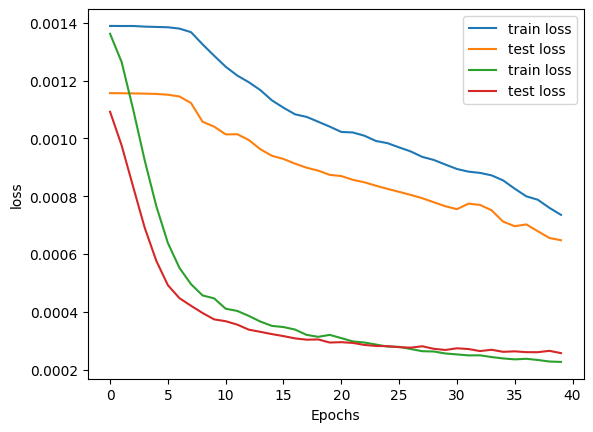

In [ ]:
plt.plot(np.arange(epoch), history_train_loss, label='train loss')
plt.plot(np.arange(epoch), history_test_loss, label='test loss')
plt.plot(np.arange(epoch), history_train_loss_2, label='train loss')
plt.plot(np.arange(epoch), history_test_loss_2, label='test loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(loc='upper left')
plt.legend()
plt.show()

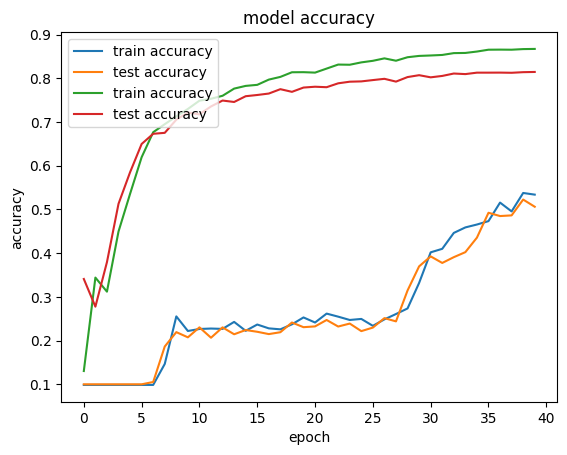

In [ ]:
plt.plot(history_train_metrics, label='train accuracy')
plt.plot(history_test_metrics, label='test accuracy')
plt.plot(history_train_metrics_2, label='train accuracy')
plt.plot(history_test_metrics_2, label='test accuracy')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

### Augmenter le nombre de données

Initialisez à nouveau le modèle et utilisez toutes les données disponibles.

In [ ]:
model = torch.nn.Sequential(torch.nn.Linear(784, 256),
                            torch.nn.ReLU(),
                            torch.nn.Linear(256, 128),
                            torch.nn.ReLU(),
                            torch.nn.Linear(128, 64),
                            torch.nn.ReLU(),
                            torch.nn.Linear(64, 32),
                            torch.nn.ReLU(),
                            torch.nn.Linear(32, 10),
                            torch.nn.LogSoftmax(dim=1))

In [ ]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model, history_train_loss_3, history_test_loss_3, history_train_metrics_3, history_test_metrics_3 = fit(model, optimizer, criterion, epoch, trainloader, testloader, number_of_good_prediction)

train_loss : 0.00075134175 test_loss : 0.00038463468
train_metric : 0.5247166666666667 test_metric : 0.7059
-------------------------------------------------------------------------------------------------
train_loss : 0.0003307547 test_loss : 0.00030691287
train_metric : 0.7416333333333334 test_metric : 0.7593
-------------------------------------------------------------------------------------------------
train_loss : 0.0002769446 test_loss : 0.00027185754
train_metric : 0.7923666666666667 test_metric : 0.8026
-------------------------------------------------------------------------------------------------
train_loss : 0.00024911267 test_loss : 0.00024804714
train_metric : 0.8199666666666666 test_metric : 0.8183
-------------------------------------------------------------------------------------------------
train_loss : 0.00022701907 test_loss : 0.00023806305
train_metric : 0.8378833333333333 test_metric : 0.8322
----------------------------------------------------------------------

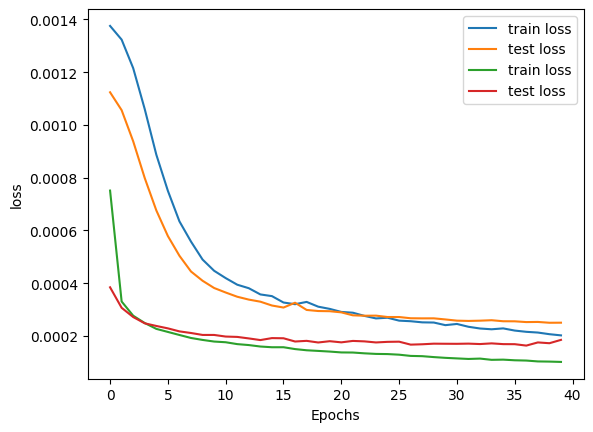

In [ ]:
plt.plot(np.arange(epoch), history_train_loss_2, label='train loss')
plt.plot(np.arange(epoch), history_test_loss_2, label='test loss')
plt.plot(np.arange(epoch), history_train_loss_3, label='train loss')
plt.plot(np.arange(epoch), history_test_loss_3, label='test loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(loc='upper left')
plt.legend()
plt.show()

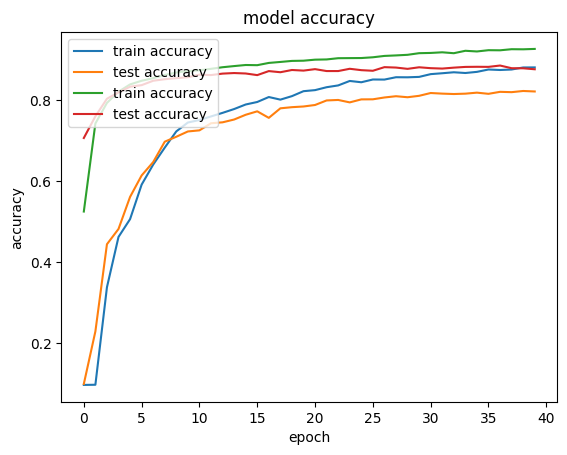

In [ ]:
plt.plot(history_train_metrics_2, label='train accuracy')
plt.plot(history_test_metrics_2, label='test accuracy')
plt.plot(history_train_metrics_3, label='train accuracy')
plt.plot(history_test_metrics_3, label='test accuracy')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

### Le drop out

Utilisez le drop out après chaque couche de votre modèle.

Aidez-vous de la [documentation](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html).

In [ ]:
model = torch.nn.Sequential(torch.nn.Linear(784, 256),
                            torch.nn.ReLU(),
                            torch.nn.Dropout(0.1),
                            torch.nn.Linear(256, 128),
                            torch.nn.ReLU(),
                            torch.nn.Dropout(0.1),
                            torch.nn.Linear(128, 64),
                            torch.nn.ReLU(),
                            torch.nn.Dropout(0.1),
                            torch.nn.Linear(64, 32),
                            torch.nn.ReLU(),
                            torch.nn.Dropout(0.1),
                            torch.nn.Linear(32, 10),
                            torch.nn.LogSoftmax(dim=1))

In [ ]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model, history_train_loss_4, history_test_loss_4, history_train_metrics_4, history_test_metrics_4 = fit(model, optimizer, criterion, epoch, trainloader, testloader, number_of_good_prediction)

train_loss : 0.00076059345 test_loss : 0.00043333796
train_metric : 0.4912166666666667 test_metric : 0.6747
-------------------------------------------------------------------------------------------------
train_loss : 0.00036403086 test_loss : 0.00033812466
train_metric : 0.7246 test_metric : 0.747
-------------------------------------------------------------------------------------------------
train_loss : 0.0003011057 test_loss : 0.00029395017
train_metric : 0.7779666666666667 test_metric : 0.7872
-------------------------------------------------------------------------------------------------
train_loss : 0.00026380317 test_loss : 0.00026702293
train_metric : 0.8122666666666667 test_metric : 0.8095
-------------------------------------------------------------------------------------------------
train_loss : 0.0002394759 test_loss : 0.00024960513
train_metric : 0.8304 test_metric : 0.8241
-----------------------------------------------------------------------------------------------

In [ ]:
plt.plot(np.arange(epoch), history_train_loss_3, label='train loss')
plt.plot(np.arange(epoch), history_test_loss_3, label='test loss')
plt.plot(np.arange(epoch), history_train_loss_4, label='train loss')
plt.plot(np.arange(epoch), history_test_loss_4, label='test loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(loc='upper left')
plt.legend()
plt.show()

In [ ]:
plt.plot(history_train_metrics_3, label='train accuracy')
plt.plot(history_test_metrics_3, label='test accuracy')
plt.plot(history_train_metrics_4, label='train accuracy')
plt.plot(history_test_metrics_4, label='test accuracy')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

On peut voir que l'erreur sur le jeu de test continue de descendre au lieu d'augmenter.